# DATA DESCRIPTION

***

- **T1w.nii**  --> structural T1-weighted image (3D)

***

- **mask.nii** --> brain mask, derived from a brain extraction procedure on the T1w data. This is a binary map, with the same dimension of the corresponding T1w

***

- **fMRI.nii** --> functional MRI data (4D), where each brain volume has been acquired multiple times. This is the fourth dimension of the fMRI data. The TR (repetition time, i.e. time between consecutive time points) is 3.5 sec.

***

- **MNI152_T1_2mm_brain.nii** --> common anatomical MNI space (MNI-2mm), 3D structure

***

- **Schaefer2018_200Parcels_7Networks_order_FSLMNI152_2mm.nii** --> reference brain atlas, consisting of 200 brain regions derived from a functional parcellation of the brain voxels/tissues, 3D structure of same dimension of anatomical MNI space

***

# PART 0
***
This part prior to the real analysis pipeline is performed to do some data exploration before starting with the real project. The aim is to gain familiarity with the data so that further examination will be much easier

- .nii format --> Neuroimaging Informatics Technology Initiative (NifTI): main standard used to archive, analyze and share brain scans (TAC, fMRI...) allowing the collection of volumetric images and temporal information in a unique file

In [9]:
import nibabel as nib
import os
import matplotlib.pyplot as plt
import numpy as np

In [2]:
DATA_PATH        = os.path.join(os.getcwd(), "data")
T1_PATH          = os.path.join(DATA_PATH, "T1w.nii")
MASK_PATH        = os.path.join(DATA_PATH, "mask.nii")
FMRI_PATH        = os.path.join(DATA_PATH, "fMRI.nii")
MNI_PATH         = os.path.join(DATA_PATH, "MNI152_T1_2mm_brain.nii")
ATLAS_PATH       = os.path.join(DATA_PATH, "Schaefer2018_200Parcels_7Networks_order_FSLMNI152_2mm.nii")
REGIONS_CSV_PATH = os.path.join(DATA_PATH, "Schaefer2018_200Parcels_7Networks_order_FSLMNI152_2mm.Centroid_RAS.csv")

In [60]:
def display_nii_info(nii_path, name):

    nii_img = nib.load(nii_path)
    nii_hdr = nii_img.header
    nii_data = nii_img.get_fdata()
    nii_dim = nii_hdr['dim'][:4]
    
    print(f"\nINFORMATION ABOUT {name} NIFTI FILE:")
    print("\n"+"-"*100)
    
    print("\n")
    print(f"Type of variable nii_img: {type(nii_img)}")
    print(f"Type of variable nii_hdr: {type(nii_hdr)}")
    print(f"Shape of the NIfTI image: {nii_img.shape}")
    print(f"Dimensions of the NIfTI image: {nii_dim}")
    print(f"Dimensions of NIfTI img data: {nii_data.shape}")
    
    print("\n"+"-"*100)
    print(nii_hdr)

    return nii_img, nii_hdr, nii_data, nii_dim


def display_slice(nii_data, slice_idx):
    
    if len(nii_data.shape) > 3:
        z_slice = nii_data[:, :, slice_idx, 0]
        assert slice_idx < nii_data.shape[3], "You need to choose a slice index < {}.".format(nii_data.shape[2])
 
    else:
        z_slice = nii_data[:, :, slice_idx]
        assert slice_idx < nii_data.shape[2], "You need to choose a slice index < {}.".format(nii_data.shape[2])

    plt.figure(figsize=(6, 4))
    plt.imshow(z_slice, cmap='gray', vmin=np.min(z_slice)), plt.grid(False)
    plt.title('Single slice, n. '+str(slice_idx)+' of {}'.format(nii_data.shape[2]))
    plt.show()

Let's extract some basic info from the T1 weighted image

In [46]:
t1_img, t1_hdr, t1_data, t1_dim = display_nii_info(T1_PATH, "T1-WEIGHTED")


INFORMATION ABOUT T1-WEIGHTED NIFTI FILE:

----------------------------------------------------------------------------------------------------


Type of variable nii_img: <class 'nibabel.nifti1.Nifti1Image'>
Type of variable nii_hdr: <class 'nibabel.nifti1.Nifti1Header'>
Shape of the NIfTI image: (176, 256, 256)
Dimensions of the NIfTI image: [  3 176 256 256]
Dimensions of NIfTI img data: (176, 256, 256)

----------------------------------------------------------------------------------------------------
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 16384
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 176 256 256   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float32
bitpix          : 32
slice_start     : 0
pixdim          : [-1.          1.          0.9765625   0.97656244  0

... and let's display some visualizations to better understand what we are dealing with

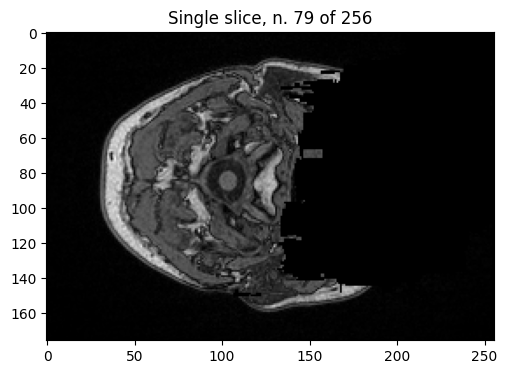

In [47]:
display_slice(t1_data, slice_idx=79)

Let's do the same for each file we have

In [48]:
mask, mask_hdr, mask_data, mask_dims = display_nii_info(MASK_PATH, 'MASK')


INFORMATION ABOUT MASK NIFTI FILE:

----------------------------------------------------------------------------------------------------


Type of variable nii_img: <class 'nibabel.nifti1.Nifti1Image'>
Type of variable nii_hdr: <class 'nibabel.nifti1.Nifti1Header'>
Shape of the NIfTI image: (176, 256, 256)
Dimensions of the NIfTI image: [  3 176 256 256]
Dimensions of NIfTI img data: (176, 256, 256)

----------------------------------------------------------------------------------------------------
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 16384
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 176 256 256   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [-1.          1.          0.9765625   0.97656244  0.        

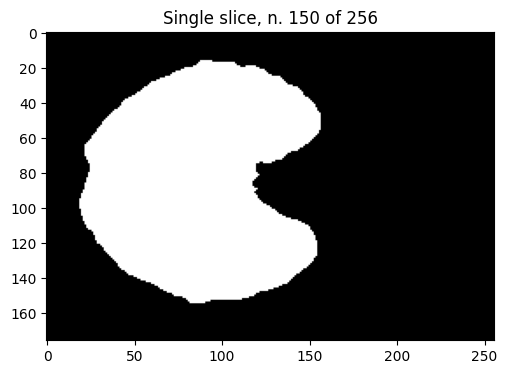

In [50]:
display_slice(mask_data, slice_idx=150)

In [51]:
fmri_img, fmri_hdr, fmri_data, fmri_dims = display_nii_info(FMRI_PATH, "FMRI")


INFORMATION ABOUT FMRI NIFTI FILE:

----------------------------------------------------------------------------------------------------


Type of variable nii_img: <class 'nibabel.nifti1.Nifti1Image'>
Type of variable nii_hdr: <class 'nibabel.nifti1.Nifti1Header'>
Shape of the NIfTI image: (64, 64, 36, 200)
Dimensions of the NIfTI image: [ 4 64 64 36]
Dimensions of NIfTI img data: (64, 64, 36, 200)

----------------------------------------------------------------------------------------------------
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  4  64  64  36 200   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [-1.         3.5937498  3.59375    3.78       3.56       0.
  0.

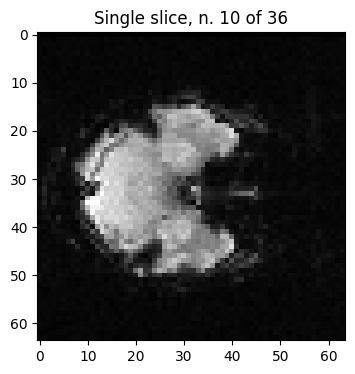

In [61]:
display_slice(fmri_data, slice_idx=10)

If the dimension of the data is [176,256,256] then the last number represents the slices, 176 rows (x direction) and 256 columns (y-direction). In 4D data, slices are represented by the third dimension

In [62]:
mni_img, mni_hdr, mni_data, mni_dims = display_nii_info(MNI_PATH, "MNI")


INFORMATION ABOUT MNI NIFTI FILE:

----------------------------------------------------------------------------------------------------


Type of variable nii_img: <class 'nibabel.nifti1.Nifti1Image'>
Type of variable nii_hdr: <class 'nibabel.nifti1.Nifti1Header'>
Shape of the NIfTI image: (91, 109, 91)
Dimensions of the NIfTI image: [  3  91 109  91]
Dimensions of NIfTI img data: (91, 109, 91)

----------------------------------------------------------------------------------------------------
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3  91 109  91   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [-1.  2.  2.  2.  1.  1.  1.  1.]
vox_offset      : 0.0
scl_slope    

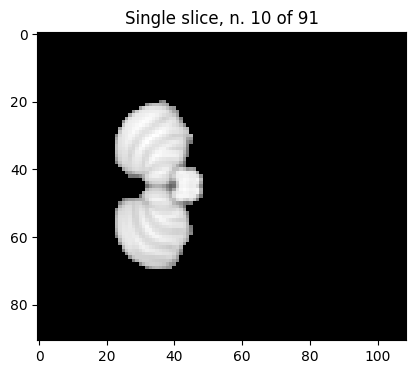

In [63]:
display_slice(mni_data, slice_idx=10)

In [64]:
atlas_img, atlas_hdr, atlas_data, atlas_dims = display_nii_info(ATLAS_PATH, "ATLAS")


INFORMATION ABOUT ATLAS NIFTI FILE:

----------------------------------------------------------------------------------------------------


Type of variable nii_img: <class 'nibabel.nifti1.Nifti1Image'>
Type of variable nii_hdr: <class 'nibabel.nifti1.Nifti1Header'>
Shape of the NIfTI image: (91, 109, 91)
Dimensions of the NIfTI image: [  3  91 109  91]
Dimensions of NIfTI img data: (91, 109, 91)

----------------------------------------------------------------------------------------------------
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b''
dim_info        : 0
dim             : [  3  91 109  91   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float32
bitpix          : 32
slice_start     : 0
pixdim          : [-1.  2.  2.  2.  0.  1.  1.  1.]
vox_offset      : 0.0
scl_slope 

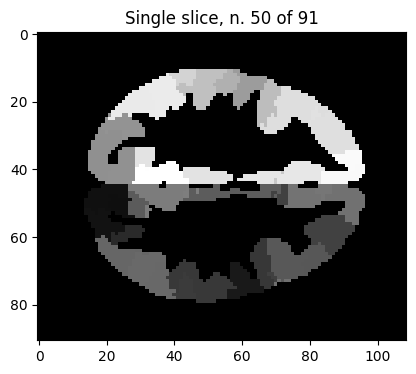

In [68]:
display_slice(atlas_data, slice_idx=50)